# Exam

> Data: **2025-01-10**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Preso da [Kaggle](https://www.kaggle.com/datasets/beridzeg45/diamonds-prices-prediction), il dataset è scaricabile attraverso il [link](http://bit.ly/4jaJgD6) e contiene dati relativi ad alcuni tipi di diamanti. Sono presenti le seguenti feature:

- `Shape`: forma del diamante.
- `Cut`: qualità del taglio del diamante (in ordine crescente: Very Good, Excellent, Ideal, Astor).
- `Color`: grado di colore del diamante da D (incolore) a Z.
- `Clarity`: grado di chiarezza basato sulle imperfezioni.
- `Carat Weight`: peso del diamante in carati.
- `Length/Width Ratio`: proporzione tra lunghezza e larghezza.
- `Depth %`: profondità del diamante come percentuale della sua larghezza.
- `Table %`: larghezza della facciata superiore in percentuale.
- `Polish`: qualità della finitura superficiale del diamante.
- `Symmetry`: precisione della forma del diamante.
- `Girdle`: spessore del bordo del diamante.
- `Culet`: dimensione della sfaccettatura inferiore.
- `Length`: lunghezza del diamante in millimetri.
- `Width`: larghezza del diamante in millimetri.
- `Height`: altezza del diamante in millimetri.
- `Price`: prezzo del diamante in dollari ($).
- `Type`: tipo di diamante (target).
- `Fluorescence`: livello di fluorescenza UV del diamante.

### Imports

In [ ]:
!curl -sLo dataset.zip "https://www.kaggle.com/api/v1/datasets/download/beridzeg45/diamonds-prices-prediction"
!unzip -o dataset.zip
!mv "diamonds (cleaned).csv" dataset.csv
# FILE_ID = "file_id"
# !curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

Archive:  dataset.zip
  inflating: diamonds (cleaned).csv  


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD

### Dataset

In [ ]:
df = pd.read_csv("dataset.csv")

#### Overview

In [ ]:
df.head()

,Shape,Cut,Color,Clarity,Carat Weight,Length/Width Ratio,Depth %,Table %,Polish,Symmetry,Girdle,Culet,Length,Width,Height,Price,Type,Fluorescence
0,Cushion Modified,Ideal,F,VVS2,1.84,1.02,65.8,59.0,Excellent,Very Good,Medium to Thick,NaN,7.09,6.95,4.57,2640,GIA Lab-Grown,NaN
1,Pear,NaN,E,VS1,1.20,1.65,62.5,58.0,Very Good,Very Good,Medium to Thick,NaN,9.64,5.86,3.66,1070,GIA Lab-Grown,NaN
2,Oval,NaN,E,VS1,1.19,1.41,63.1,63.0,Very Good,Very Good,Medium to Thick,NaN,8.44,6.00,3.79,1070,GIA Lab-Grown,NaN
3,Heart,NaN,D,IF,1.00,1.18,61.7,58.0,Excellent,Excellent,Slightly Thick to Very Thick,NaN,5.85,6.89,4.25,7110,GIA,Faint
4,Radiant,NaN,H,VS1,1.01,1.35,69.4,66.0,Excellent,Very Good,Thick,NaN,6.80,5.05,3.50,3050,GIA,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6485 entries, 0 to 6484
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Shape               6480 non-null   object 
 1   Cut                 2182 non-null   object 
 2   Color               6480 non-null   object 
 3   Clarity             6480 non-null   object 
 4   Carat Weight        6480 non-null   float64
 5   Length/Width Ratio  6480 non-null   float64
 6   Depth %             6478 non-null   float64
 7   Table %             6468 non-null   float64
 8   Polish              6465 non-null   object 
 9   Symmetry            6465 non-null   object 
 10  Girdle              6463 non-null   object 
 11  Culet               1891 non-null   object 
 12  Length              6465 non-null   float64
 13  Width               6465 non-null   float64
 14  Height              6465 non-null   float64
 15  Price               6485 non-null   int64  
 16  Type  

#### Instances

In [ ]:
df.shape

(6485, 18)

#### Missing values

In [ ]:
df.isnull().sum().sum()

np.int64(14332)

In [ ]:
df.isnull().sum()

,0
Shape,5
Cut,4303
Color,5
Clarity,5
Carat Weight,5
Length/Width Ratio,5
Depth %,7
Table %,17
Polish,20
Symmetry,20


#### Balancing

In [ ]:
df["Type"].value_counts()

,count
Type,
GIA,3355
IGI Lab-Grown,1876
GIA Lab-Grown,1254


<Axes: >

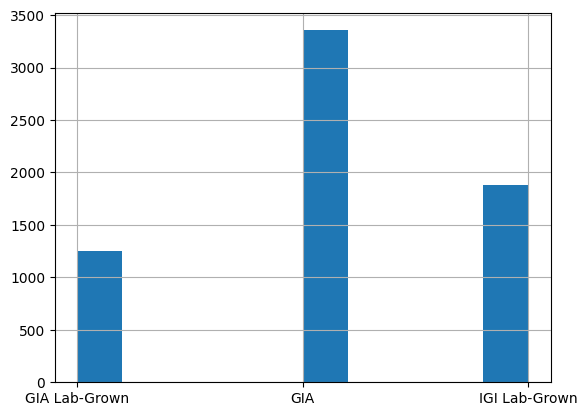

In [ ]:
df["Type"].hist()

##

---

## Parte 1: Analisi (Punti 10)

### Domanda 01 (Punti 1)

Quante sono le istanze contenute nel dataset? Il dataset è completo (cioè per ogni istanza tutti i valori di ogni attributo sono sempre correttamente specificati - non esistono "missing values")? Il dataset è bilanciato per quanto riguarda la classe da predire?

In [ ]:
df.shape[0]

6485

> Il dataset contiene 6485 istanze al suo interno.

In [ ]:
df.isnull().sum().sum()

np.int64(14332)

In [ ]:
df.isnull().sum()

,0
Shape,5
Cut,4303
Color,5
Clarity,5
Carat Weight,5
Length/Width Ratio,5
Depth %,7
Table %,17
Polish,20
Symmetry,20


> No, il dataset non è completo in quanto presenta 14332 missing values. Nello specifico, gli attributi che presentano più istanze con missing values sono `Fluorescence`, `Culet` e `Cut`.

In [ ]:
df["Type"].value_counts()

,count
Type,
GIA,3355
IGI Lab-Grown,1876
GIA Lab-Grown,1254


> Il dataset non è troppo bilanciato rispetto l'attributo target `Type`. Il valore `GIA` è presenta più della somma degli altri due valori, ovvero `IGI Lab-Grown` e `GIA Lab-Grown`.

---

### Domanda 02 (Punti 2)

Calcolare in una nuova colonna il volume approssimato del diamante come `Length * Width * Height` e verificare con un opportuno grafico se c'è una relazione tra il volume e il prezzo: i diamanti più grandi sono quelli più costosi?

In [ ]:
df["Volume"] = df["Length"] * df["Width"] * df["Height"]
df[["Length", "Width", "Height", "Volume", "Price"]]

,Length,Width,Height,Volume,Price
0,7.09,6.95,4.57,225.189035,2640
1,9.64,5.86,3.66,206.754864,1070
2,8.44,6.00,3.79,191.925600,1070
3,5.85,6.89,4.25,171.302625,7110
4,6.80,5.05,3.50,120.190000,3050
...,...,...,...,...,...
6480,8.60,5.59,3.51,168.739740,3760
6481,6.05,6.99,4.07,172.118265,4710
6482,5.59,5.51,4.00,123.203600,3270
6483,7.24,5.05,3.42,125.042040,1050


<Axes: xlabel='Volume'>

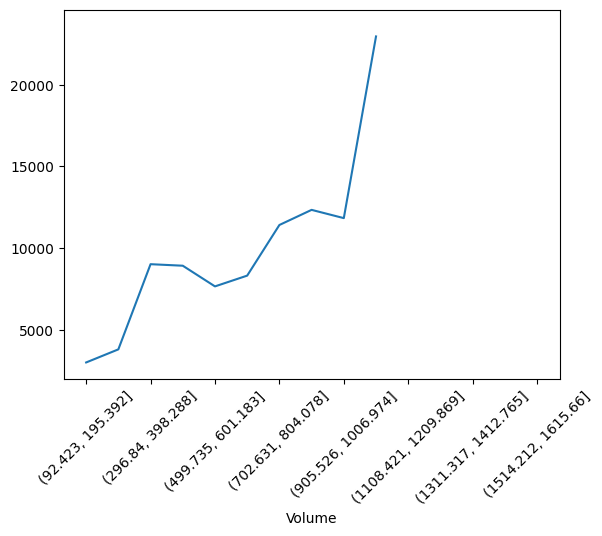

In [ ]:
volume_bins = pd.cut(df["Volume"], bins=15)
df.groupby(volume_bins, observed=False)["Price"].mean().plot(rot=45)

<Axes: xlabel='Volume'>

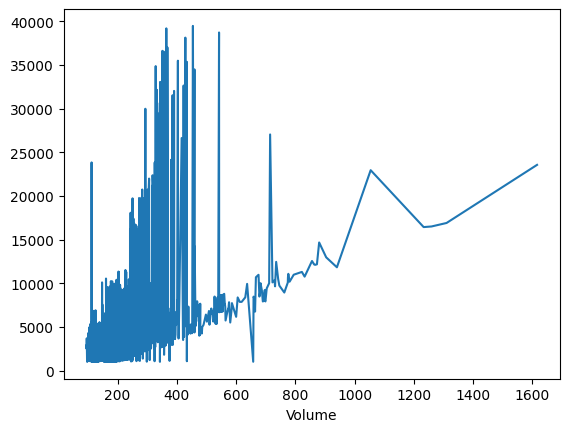

In [ ]:
df.groupby("Volume")["Price"].mean().plot()

> Dal primo grafico, nel quale è stato suddiviso il volume in differenti intervalli, possiamo notare come ci sia effettivamente una relazione tra l'aumento del volume con il relativo aumento di prezzo.
>
> Ma dal secondo grafico, nel quale sono stati inserite tutte le istanze, possiamo notare come effettivamente i diamanti più costosi non sono necessariamente i più grandi. Infatti, i diamanti più costosi, stando sempre al secondo grafico, hanno un volume che si aggira attorno a 400, a grandi linee tra 350 e 450. Questo vuole dire che i diamanti più costosi non sono quelli con volume maggiore.

---

### Domanda 03 (Punti 3)

Considerare soltanto i record con valore non nullo di `Cut` e discretizzare la variabile `Carat Weight` in 5 gruppi. Verificare attraverso una tabella pivot se è vero che il prezzo medio aumenta all'aumentare della qualità del taglio e del peso in carati.

In [ ]:
carat_weight_bins = pd.cut(df["Carat Weight"], bins=[0, 1, 2, 3, 4, 5])
carat_weight_bins

,Carat Weight
0,"(1, 2]"
1,"(1, 2]"
2,"(1, 2]"
3,"(0, 1]"
4,"(1, 2]"
...,...
6480,"(1, 2]"
6481,"(0, 1]"
6482,"(1, 2]"
6483,"(1, 2]"


In [ ]:
pd.pivot_table(df, index=df["Cut"].dropna(), columns=carat_weight_bins, values="Price", aggfunc="mean", observed=False)

Carat Weight,"(0, 1]","(1, 2]","(2, 3]","(3, 4]","(4, 5]"
Cut,,,,,
Astor,4140.000000,5521.428571,NaN,NaN,NaN
Excellent,3906.272727,2482.558140,NaN,NaN,NaN
Ideal,2819.902913,2343.100698,4844.114286,6897.857143,7680.0
Very Good,3534.809160,3220.157480,NaN,NaN,NaN


> Come prima osservazione possiamo notare che sopra i 2 carati, il diamante viene tagliato solamente nella tipologia `Ideal`.
>
> Considerando invece il taglio e i carati sembrerebbe esserci un trend crescente sul prezzo all'aumentare della qualità del taglio e dei carati, ad esclusione del taglio `Very Good`, il quale ha prezzi medi per entrambe le prime due fasce di carati rispetto a tagli più pregiati.

---

### Domanda 04 (Punti 4)

Si vuole analizzare il prezzo a carato per ogni tipo di diamante: creare una nuova feature che rappresenta il prezzo per carato (`Price / Carat Weight`) e visualizzare attraverso dei boxplot come varia questo prezzo per ogni tipo (`Type`) di diamante.

In [ ]:
df["Carat Price"] = df["Price"] / df["Carat Weight"]
df[["Price", "Carat Weight", "Carat Price", "Type"]]

,Price,Carat Weight,Carat Price,Type
0,2640,1.84,1434.782609,GIA Lab-Grown
1,1070,1.20,891.666667,GIA Lab-Grown
2,1070,1.19,899.159664,GIA Lab-Grown
3,7110,1.00,7110.000000,GIA
4,3050,1.01,3019.801980,GIA
...,...,...,...,...
6480,3760,1.02,3686.274510,GIA
6481,4710,1.00,4710.000000,GIA
6482,3270,1.03,3174.757282,GIA
6483,1050,1.06,990.566038,GIA Lab-Grown


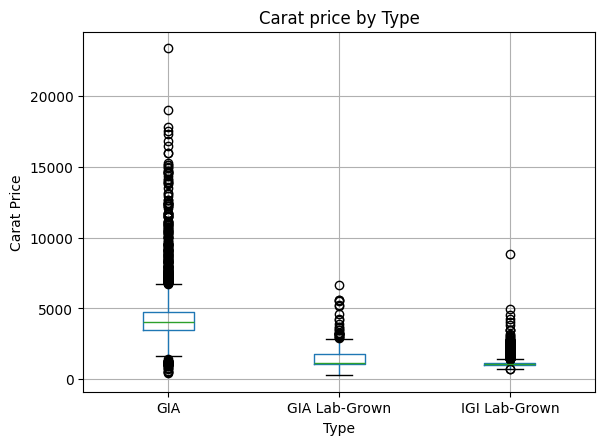

In [ ]:
df.boxplot(column="Carat Price", by="Type")
# PLOT VISUALIZATION, NOT MANDATORY
plt.title("Carat price by Type")
plt.suptitle("")
plt.xlabel("Type")
plt.ylabel("Carat Price")
plt.show()

> Possiamo notare come la tipologia che ha un prezzo per carato maggiore è `GIA`, mentre i `Lab-Grown` sono più economici. Inoltre, tutte le tipologie presentano outlier, nello specifico per `GIA` questi sono molto variabili.

##

---

## Parte 2: Trasformazione e Predizione (Punti 20)

### Domanda 01 (Punti 4)

Si vuole predire la tipologia di diamante (`Type`). Ricaricare il dataset originale, eliminare eventuali attributi inutili (giustificare la scelta), eliminare gli attributi con più del 50% di valori nulli, eliminare le istanze che contengono valori nulli, trasformare opportunamente valori categorici e dividere il dataset in modo che 3/4 degli elementi siano contenuti in un nuovo dataset "train" e 1/4 nel dataset "test" preservando le proporzioni delle classi nella colonna target.

Confrontare la predizione ottenuta sia sul dataset train sia sul dataset test dai classificatori DecisionTree, KNeighborsClassifier e da un dummy classifier a scelta. Effettuare alcune considerazioni sui risultati ottenuti, tenendo in considerazione i valori di F1 (con *average="weighted"*) e della confusion matrix.

In [ ]:
df = pd.read_csv("dataset.csv")
df.dropna(axis=1, thresh=int(df.shape[0] * 0.5), inplace=True)
df.dropna(axis=0, inplace=True)
df.select_dtypes(include="object")

,Shape,Color,Clarity,Polish,Symmetry,Girdle,Type
0,Cushion Modified,F,VVS2,Excellent,Very Good,Medium to Thick,GIA Lab-Grown
1,Pear,E,VS1,Very Good,Very Good,Medium to Thick,GIA Lab-Grown
2,Oval,E,VS1,Very Good,Very Good,Medium to Thick,GIA Lab-Grown
3,Heart,D,IF,Excellent,Excellent,Slightly Thick to Very Thick,GIA
4,Radiant,H,VS1,Excellent,Very Good,Thick,GIA
...,...,...,...,...,...,...,...
6480,Pear,F,VS2,Excellent,Very Good,Thick to Very Thick,GIA
6481,Heart,E,VVS2,Excellent,Excellent,Slightly Thick to Very Thick,GIA
6482,Princess,G,VVS1,Excellent,Excellent,Medium to Slightly Thick,GIA
6483,Radiant,E,VS1,Excellent,Excellent,Slightly Thick to Thick,GIA Lab-Grown


In [ ]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
categorical_columns = df.select_dtypes(include="object").columns
df[categorical_columns] = encoder.fit_transform(df[categorical_columns])

In [ ]:
X, y = df.drop("Type", axis=1), df["Type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=0, stratify=y)

In [ ]:
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=0),
    "KNeighbors": KNeighborsClassifier(),
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=0)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(f"{name}")
    print("=" * 30)
    print("TRAIN")
    print("    Accuracy:", accuracy_score(y_train, y_pred_train))
    print("    F1:", f1_score(y_train, y_pred_train, average="weighted"))
    print(confusion_matrix(y_train, y_pred_train))
    print("-" * 30)
    print("TEST")
    print("    Accuracy:", accuracy_score(y_test, y_pred_test))
    print("    F1:", f1_score(y_test, y_pred_test, average="weighted"))
    print(confusion_matrix(y_test, y_pred_test))
    print("=" * 30)
    print()

DecisionTree
TRAIN
    Accuracy: 1.0
    F1: 1.0
[[2509    0    0]
 [   0  935    0]
 [   0    0 1403]]
------------------------------
TEST
    Accuracy: 0.9245049504950495
    F1: 0.9242839737049535
[[831   4   2]
 [  4 248  60]
 [  2  50 415]]

KNeighbors
TRAIN
    Accuracy: 0.8570249638951929
    F1: 0.8496508975723568
[[2451   38   20]
 [ 235  529  171]
 [ 119  110 1174]]
------------------------------
TEST
    Accuracy: 0.8236386138613861
    F1: 0.8106255547275772
[[812  18   7]
 [ 78 135  99]
 [ 39  44 384]]

Dummy
TRAIN
    Accuracy: 0.5176397771817619
    F1: 0.3531153346789126
[[2509    0    0]
 [ 935    0    0]
 [1403    0    0]]
------------------------------
TEST
    Accuracy: 0.5179455445544554
    F1: 0.3534614111635379
[[837   0   0]
 [312   0   0]
 [467   0   0]]



> Dalle metriche possiamo dire che il modello migliore tra i tre risulta essere il `DecisionTree`. Questo modello ha valori di F1, e di accuracy, circa del 92% sul dataset di test, sul dataset di train presenta performance perfette, ma questo deriva intrinsecamente dalla tipologia del modello, un albero decisionale. Analizzando anche la confusion matrix possiamo notare come ci siano pochi errori di classificazione per ogni classe.
>
> Il modello `KNeighbors`, invece, presenta performance intorno all'81% sul dataset di test. Un buon risultato ma inferiore a quello ottenuto dal `DecisionTree`. Questo modello, a differenza del precedente, ha performance simili anche sul dataset di train. Inoltre, possiamo notare come il `KNeighbors` commetta errori principalmente nella classificazione della classe 1, la quale presenta dei valori non troppo distanti dalla classe principale.
>
> Il modello `Dummy` ovviamente presenta metriche scadenti, in quanto è un modello che predice casualmente. In questo caso il modello predice sempre e solamente la classe più frequente, portando quindi ad avere performance non buone.

---

### Domanda 02 (Punti 1)

Confrontare i valori di F1 ottenuti nel punto precedente con quelli che si ottengono con una 10 Fold cross validation.

In [ ]:
for name, model in models.items():
  scores = cross_val_score(model, X, y, cv=10, scoring="f1_weighted")
  print(f"{name}")
  print("=" * 30)
  print("    Mean:", scores.mean())
  print("    Scores:", scores)
  print("=" * 30)
  print()

DecisionTree
    Mean: 0.9300027497129856
    Scores: [0.93171303 0.93122809 0.93343213 0.9225218  0.9079062  0.93022236
 0.94751508 0.93517234 0.93294975 0.92736671]

KNeighbors
    Mean: 0.8107956689855745
    Scores: [0.80262473 0.82418215 0.82303051 0.80728535 0.77667361 0.8199103
 0.82726707 0.79819494 0.80637761 0.82241041]

Dummy
    Mean: 0.35320206242655927
    Scores: [0.35326763 0.35326763 0.35326763 0.35242307 0.35242307 0.35242307
 0.35242307 0.35417515 0.35417515 0.35417515]



> Attraverso il 10 fold cross validation possiamo notare come le performance del `KNeighbors` rimangano pressoché le stesse, mentre il modello `DecisionTree` migliora di quasi un punto percentuale.

---

### Domanda 03 (Punti 4)

Attraverso la tecnica Permutation Feature Importance (PFI) e considerando il classificatore KNeighborsClassifier, analizzare la feature importance del dataset utilizzato al punto 1. Applicare 5 permutazioni per ogni feature. Quali risultano essere le 2 feature più importanti?

In [ ]:
# MANUAL CODE
kneighbors = models["KNeighbors"]

n_permutations = 5
f1_permutations = []
features = X_test.columns
y_pred = kneighbors.predict(X_test)
f1_original = f1_score(y_test, y_pred, average="weighted")

for feature in features:
    f1_per_feature = []
    for _ in range(n_permutations):
        X_test_shuffled = X_test.copy()
        X_test_shuffled[feature] = np.random.permutation(X_test_shuffled[feature])
        y_pred_shuffled = kneighbors.predict(X_test_shuffled)
        f1_shuffled = f1_score(y_test, y_pred_shuffled, average="weighted")
        f1_per_feature.append(f1_shuffled)
    f1_permutations.append(f1_per_feature)

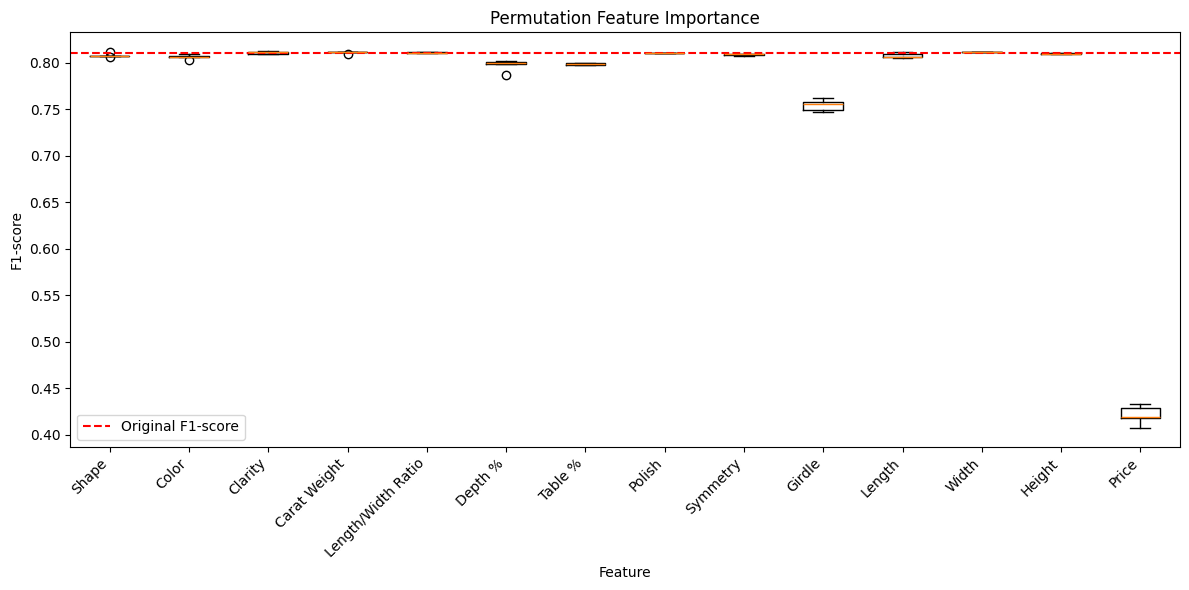

In [ ]:
plt.figure(figsize=(12, 6))
plt.boxplot(f1_permutations, tick_labels=features)
plt.title("Permutation Feature Importance")
plt.xlabel("Feature")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.axhline(y=f1_original, color="r", linestyle="--", label="Original F1-score")
plt.legend()
plt.show()

> Valori valutari rispetto l'F1 originale. Più vicino a questo valore, meno la feature è importante, in quanto non altera la metrica. Più lontana, invece, più la feature è importante, degradando le performance.

In [ ]:
f1_permutations_means = np.array(f1_permutations).mean(axis=1)

sorted_indices = np.argsort(f1_permutations_means)
sorted_means = f1_permutations_means[sorted_indices]
sorted_features = features[sorted_indices]

for feature, mean in zip(sorted_features, sorted_means):
    print(f"{feature:20}: {mean}")

Price               : 0.4213897342755528
Girdle              : 0.7546138569356341
Depth %             : 0.7978108226374071
Table %             : 0.7990235348214304
Color               : 0.8066238056457218
Shape               : 0.808116958835328
Length              : 0.8081376219709849
Symmetry            : 0.808710107299763
Height              : 0.8100344563497366
Polish              : 0.8106422647057144
Length/Width Ratio  : 0.810973576020988
Carat Weight        : 0.811152123014425
Clarity             : 0.8112138227001502
Width               : 0.8117642317217765


In [ ]:
# BUILT-IN CODE
kneighbors = models["KNeighbors"]
n_permutations = 5

importance = permutation_importance(kneighbors, X_test, y_test, scoring="f1_weighted", n_repeats=n_permutations)

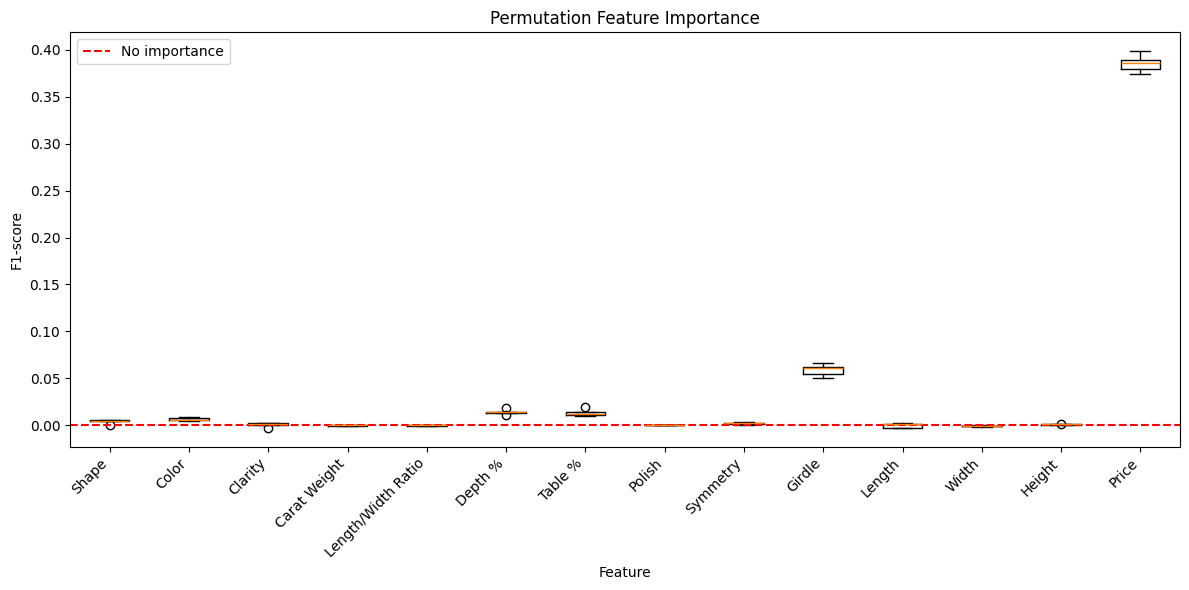

In [ ]:
plt.figure(figsize=(12, 6))
plt.boxplot(importance.importances.T, tick_labels=features)
plt.title("Permutation Feature Importance")
plt.xlabel("Feature")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.axhline(y=0, color="r", linestyle="--", label="No importance")
plt.legend()
plt.show()

> Valori valutati rispetto allo 0. La PFI built-in effettua la differenza con l'F1 originale, quindi più vicina allo 0, più la feature non è importante, non alterando le performance. Al contrario, più lontana dallo 0, più la feature è rilevante al fine delle predizioni.

In [ ]:
sorted_indices = importance.importances_mean.argsort()[::-1]
sorted_means = importance.importances_mean[sorted_indices]
sorted_features = features[sorted_indices]

for feature, mean in zip(sorted_features, sorted_means):
    print(f"{feature:20}: {mean}")

Price               : 0.38571996111531553
Girdle              : 0.058877801968049856
Depth %             : 0.013875233221702388
Table %             : 0.01297419983414141
Color               : 0.0063541543902938535
Shape               : 0.004070948699736387
Symmetry            : 0.0018781027367690494
Height              : 0.0007995387243783236
Clarity             : 0.0006728748285943275
Polish              : 0.0
Length              : -3.861126806661286e-05
Length/Width Ratio  : -0.0003284272030776192
Carat Weight        : -0.0003666222422493037
Width               : -0.0008658804432013945


> Possiamo notare come le due feature più importanti all'interno del dataset sono `Price` e `Gridle`, le uniche che influenzano significativamente la metrica.

---

### Domanda 04 (Punti 2)

A partire dal dataset utilizzato al punto 1, trovare i valori migliori dei parametri `weights` e `n_neighbors` del classificatore KNeighborsClassifier. Come varia il valore di F1?

In [ ]:
X, y = df.drop("Type", axis=1), df["Type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=0, stratify=y)

In [ ]:
params = {
    "weights": ["uniform", "distance"],
    "n_neighbors": [2, 5, 9, 13]
}
grid_search = GridSearchCV(
    estimator=kneighbors,
    param_grid=params,
    scoring="f1_weighted",
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("F1:", f1_score(y_test, y_pred, average="weighted"))

Best params: {'n_neighbors': 5, 'weights': 'distance'}
Best score: 0.8104255577117188
F1: 0.8195292158909055


> I parametri migliori di `weights` e `n_neighbors` per `KNeighbors` sono rispettivamente `5` e `distance`.
>
> Le performance del modello non cambiano significativamente, rimangono intorno all'81% sul dataset di test.

---

### Domanda 05 (Punti 3)

Creare una pipeline in cui, a partire dal dataset utilizzato al punto precedente, i valori degli attributi `Length`, `Width`, `Height` sono discretizzati in 5 intervalli, la variabile `Price` è scalata nell'intervallo 0-1 e tutti gli altri attributi sono lasciati invariati. Applicare il KNeighborsClassifier con i valori migliori dei parametri analizzati nel punto precedente e confrontare i risultati.

In [ ]:
discretizer = KBinsDiscretizer(n_bins=5)
scaler = StandardScaler()

column_transformer = ColumnTransformer(
    transformers=[
        ("discretizer", discretizer, ["Length", "Width", "Height"]),
        ("scaler", scaler, ["Price"])
    ],
    remainder="passthrough",
)
column_transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('discretizer', KBinsDiscretizer(),
                                 ['Length', 'Width', 'Height']),
                                ('scaler', StandardScaler(), ['Price'])])

In [ ]:
best_n_neighbors = grid_search.best_params_["n_neighbors"]
best_weights = grid_search.best_params_["weights"]
kneighbors = KNeighborsClassifier(n_neighbors=best_n_neighbors, weights=best_weights)

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("kneighbors", kneighbors),
    ],
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('discretizer',
                                                  KBinsDiscretizer(),
                                                  ['Length', 'Width',
                                                   'Height']),
                                                 ('scaler', StandardScaler(),
                                                  ['Price'])])),
                ('kneighbors', KNeighborsClassifier(weights='distance'))])

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("F1:", f1_score(y_test, y_pred, average="weighted"))
print(confusion_matrix(y_test, y_pred))

F1: 0.8794604227175294
[[790  15  32]
 [ 17 213  82]
 [  6  42 419]]


> Possiamo notare come la pipeline, utilizzando i valori ottimali per il modello `KNeighbors`, ottiene delle metriche migliori rispetto ai punti precedenti, arrivando a ottenere quasi 88% nella metrica F1.

---

### Domanda 06 (Punti 3)

Creare una pipeline che, a partire dal dataset iniziale a cui sono stati rimossi gli attributi con più del 50% di valori nulli, trasforma le colonne testuali in valori numerici, applica il SimpleImputer per sostituire i valori nulli, trasforma tutte le feature attraverso lo Standard Scaler e applica il KNeighborsClassifier.

In [ ]:
df = pd.read_csv("dataset.csv")
df.dropna(axis=1, thresh=int(df.shape[0] * 0.5), inplace=True)
df.dropna(axis=0, inplace=True)

In [ ]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df["Type"] = encoder.fit_transform(df[["Type"]])

In [ ]:
X, y = df.drop("Type", axis=1), df["Type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=0, stratify=y)

In [ ]:
categorical_columns = X.select_dtypes(include="object").columns

column_transformer = ColumnTransformer(
    transformers=[
        ("encoder", encoder, categorical_columns),
    ],
    remainder="passthrough",
)
column_transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('encoder',
                                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 Index(['Shape', 'Color', 'Clarity', 'Polish', 'Symmetry', 'Girdle'], dtype='object'))])

In [ ]:
imputer = SimpleImputer()
scaler = StandardScaler()

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("imputer", imputer),
        ("scaler", scaler),
        ("kneighbors", kneighbors),
    ],
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Shape', 'Color', 'Clarity', 'Polish', 'Symmetry', 'Girdle'], dtype='object'))])),
                ('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('kneighbors', KNeighborsClassifier(weights='distance'))])

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("F1:", f1_score(y_test, y_pred, average="weighted"))
print(confusion_matrix(y_test, y_pred))

F1: 0.9147369060940221
[[828   5   4]
 [  8 228  76]
 [  1  42 424]]


> In questa seconda pipeline, le metriche migliorano ulteriormente rispetto i precedenti test. In questa pipeline si arriva a superare la soglia del 90% di F1 sul dataset di test.

---

### Domanda 07 (Punti 3)

Aggiungere alla pipeline del punto precedente (dopo lo Standard Scaler) la decomposizione TruncatedSVD. Valutare il valore migliore per il numero di componenti di TruncatedSVD tra 2, 4 e 6 e i valori migliori di n_neighbors e weights del KNeighborsClassifier.

In [ ]:
X, y = df.drop("Type", axis=1), df["Type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=0, stratify=y)

In [ ]:
svd = TruncatedSVD()

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("imputer", imputer),
        ("scaler", scaler),
        ("svd", svd),
        ("kneighbors", kneighbors),
    ],
)
pipeline

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Shape', 'Color', 'Clarity', 'Polish', 'Symmetry', 'Girdle'], dtype='object'))])),
                ('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('svd', TruncatedSVD()),
                ('kneighbors', KNeighborsClassifier(weights='distance'))])

In [ ]:
params = {
    "svd__n_components": [2, 4, 6],
    "kneighbors__n_neighbors": [2, 5, 9, 13],
    "kneighbors__weights": ["uniform", "distance"],
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    scoring="f1_weighted",
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("F1:", f1_score(y_test, y_pred, average="weighted"))

Best params: {'kneighbors__n_neighbors': 5, 'kneighbors__weights': 'distance', 'svd__n_components': 6}
Best score: 0.8925633144709645
F1: 0.8902705836351611


> Le performance di quest'ultima pipeline sono leggermente inferiori di quelle ottenute nel punto precedente, anche se solo di uno o due punti percentuali.
>
> I valori ottimali ottenuti per `n_neighbors`, `weights` e `n_components` sono rispettivamente `5`, `distance`, `6`. Quest'ultimo valore è proprio il motivo principale di questo leggero degrado delle performance, in quanto vengono ridotte le features a solamente 6. Per averne la conferma possiamo provare ad aggiungere 10 al `GridSearchCV` per verificare se aumentano. In caso affermativo, questo valore era il componente che ne degradava le performance.

In [ ]:
params = {
    "svd__n_components": [2, 4, 6, 10],
    "kneighbors__n_neighbors": [2, 5, 9, 13],
    "kneighbors__weights": ["uniform", "distance"],
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    scoring="f1_weighted",
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("F1:", f1_score(y_test, y_pred, average="weighted"))

Best params: {'kneighbors__n_neighbors': 5, 'kneighbors__weights': 'distance', 'svd__n_components': 10}
Best score: 0.9204853423088053
F1: 0.9187996479536643
